In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import datetime



df = pd.read_csv('/Users/utkugulbardak/Desktop/data/Paragon/paragontoday_cleaned.csv')

df.head()

,COMPANY_NAME,PLANT_NAME,EQUIPMENT_CODE,COUNTER_CODE,SHOT_START_TIME,SHOT_END_TIME,CYCLE_TIME_LIMIT1,CYCLE_TIME_LIMIT1UNIT,CYCLE_TIME_LIMIT2,CYCLE_TIME_LIMIT2UNIT,...,TOTAL_SESSION_TIME,START_TIME,END_TIME,IDLE_TIME,UPTIME_PERCENTAGE,DAY,MONTH,QUARTER,YEAR,WEEK
0,Albea Rigid Packaging Surabaya PT,ARPS,CM316/4009 Base,EMA2349M11233,1727940704000000000,1727944250000000000,2.0,SECOND,5.0,SECOND,...,3612,20241003 07:31:44,20241003 08:30:50,42,98.84,20241003,202410,20244,2024,202440
1,Albea Rigid Packaging Surabaya PT,ARPS,CM316/4009 Base,EMA2349M11233,1728349902000000000,1728353457000000000,2.0,SECOND,5.0,SECOND,...,3597,20241008 01:11:42,20241008 02:10:57,43,98.80,20241008,202410,20244,2024,202441
2,Albea Rigid Packaging Surabaya PT,ARPS,BT8474-1,EMA2349M11245,1730148821000000000,1730152400000000000,2.0,SECOND,3.0,SECOND,...,3643,20241028 20:53:41,20241028 21:53:20,24,99.34,20241028,202410,20244,2024,202444
3,Albea Rigid Packaging Surabaya PT,ARPS,BT8474-1,EMA2349M11245,1731224720000000000,1731228298000000000,2.0,SECOND,3.0,SECOND,...,3659,20241110 07:45:20,20241110 08:44:58,243,93.36,20241110,202411,20244,2024,202445
4,Albea Rigid Packaging Surabaya PT,ARPS,BT8474-1,EMA2349M11245,1731836728000000000,1731840304000000000,2.0,SECOND,3.0,SECOND,...,3611,20241117 09:45:28,20241117 10:45:04,23,99.36,20241117,202411,20244,2024,202446


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98970 entries, 0 to 98969
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   COMPANY_NAME           98970 non-null  object 
 1   PLANT_NAME             97741 non-null  object 
 2   EQUIPMENT_CODE         97741 non-null  object 
 3   COUNTER_CODE           98970 non-null  object 
 4   SHOT_START_TIME        98970 non-null  int64  
 5   SHOT_END_TIME          98970 non-null  int64  
 6   CYCLE_TIME_LIMIT1      97741 non-null  float64
 7   CYCLE_TIME_LIMIT1UNIT  97741 non-null  object 
 8   CYCLE_TIME_LIMIT2      97741 non-null  float64
 9   CYCLE_TIME_LIMIT2UNIT  97741 non-null  object 
 10  L1_ABOVE_ADJUSTED      97741 non-null  float64
 11  L2_ABOVE_ADJUSTED      97741 non-null  float64
 12  L1_BELOW_ADJUSTED      97741 non-null  float64
 13  L2_BELOW_ADJUSTED      97741 non-null  float64
 14  CONTRACTED_CYCLE_TIME  97741 non-null  float64
 15  AV

In [23]:
# Filter the data to only include records from 2024 onward
df_filtered = df[df['YEAR'] >= 2024]





In [28]:
weekly_data = df_filtered.groupby(['YEAR', 'WEEK', 'COMPANY_NAME']).agg(
    total_shot_count=('SHOT_COUNT','sum'),  
    avg_cycle_time=('CONTRACTED_CYCLE_TIME','mean'),   
    total_break_time=('IDLE_TIME','sum'),  
    total_production_time=('PRODUCTION_TIME','sum'),    
    total_above=('ABOVE_COUNT','sum'),
    total_within=('WITHIN_COUNT','sum'),
    total_below=('BELOW_COUNT','sum'), 
    uptime_percentage=('UPTIME_PERCENTAGE','mean'),    
    
).reset_index()


In [29]:
#same but monthly

monthly_data = df_filtered.groupby(['YEAR', 'MONTH', 'COMPANY_NAME']).agg(    
    total_shot_count=('SHOT_COUNT','sum'),  
    avg_cycle_time=('CONTRACTED_CYCLE_TIME','mean'),   
    total_break_time=('IDLE_TIME','sum'),  
    total_production_time=('PRODUCTION_TIME','sum'),    
    total_above=('ABOVE_COUNT','sum'),
    total_within=('WITHIN_COUNT','sum'),
    total_below=('BELOW_COUNT','sum'), 
    uptime_percentage=('UPTIME_PERCENTAGE','mean'),   
).reset_index()



In [22]:
# import matplotlib.pyplot as plt

# #trend of uptime percentage for each company
# for company in weekly_data['COMPANY_NAME'].unique():
#     company_data = weekly_data[weekly_data['COMPANY_NAME'] == company]
#     plt.plot(company_data['WEEK'], company_data['UPTIME_PERCENTAGE'], label=company)
    
#     plt.xlabel('Week')
#     plt.ylabel('Uptime Percentage')
#     plt.title('Uptime Percentage Trend by Company')
#     plt.legend()
#     plt.show()

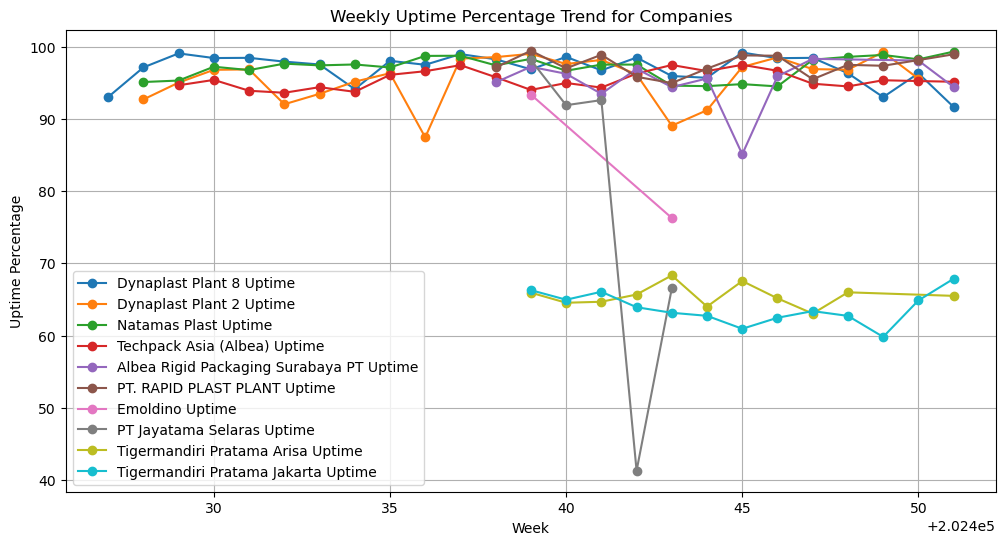

In [30]:
# Filter the data to only include records from 2024 onward
df_filtered = df[df['YEAR'] >= 2024]


# Trend of Uptime Percentage over time for each company
plt.figure(figsize=(12, 6))

# Loop through each company and plot its trend
for company in weekly_data['COMPANY_NAME'].unique():
    company_data = weekly_data[weekly_data['COMPANY_NAME'] == company]
    plt.plot(company_data['WEEK'], company_data['uptime_percentage'], label=f'{company} Uptime', linestyle='-', marker='o')

# Customize the plot
plt.xlabel('Week')
plt.ylabel('Uptime Percentage')
plt.title('Weekly Uptime Percentage Trend for Companies')
plt.legend()
plt.grid(True)
plt.show()


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_84642/3589639008.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=8.0)  # Increased padding to provide enough space


<Figure size 4000x2200 with 0 Axes>

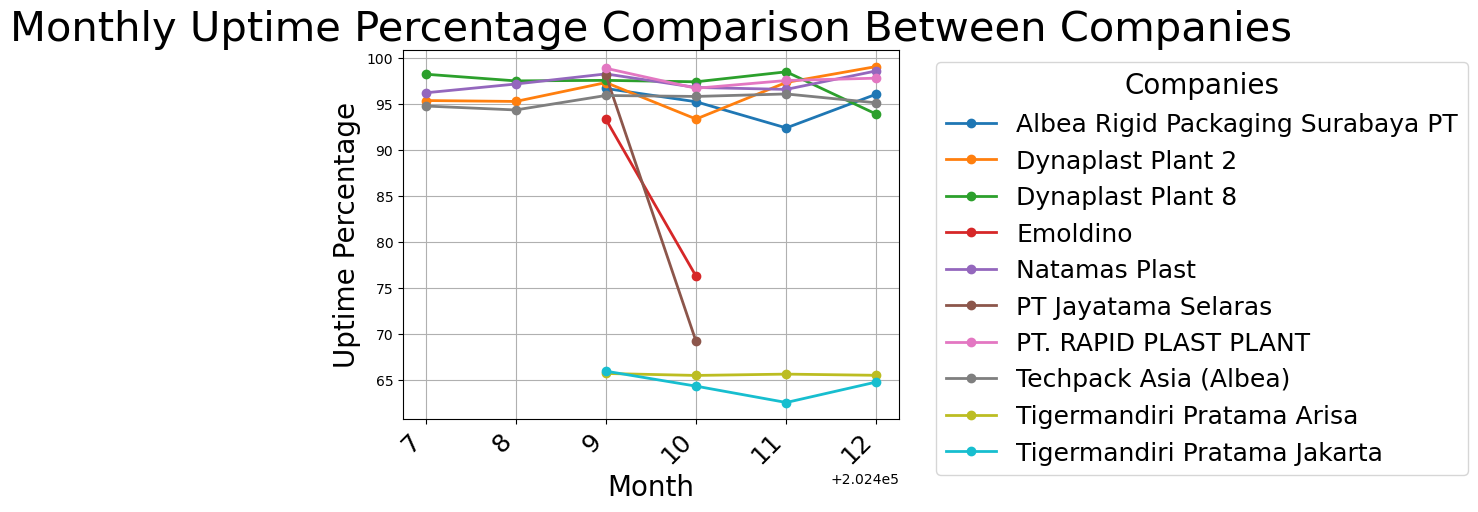

In [42]:
# Pivot the data to have companies as columns and weeks as the index
uptime_comparison = monthly_data.pivot(index='MONTH', columns='COMPANY_NAME', values='uptime_percentage')

# Create a larger figure to accommodate the data and the legend
plt.figure(figsize=(40, 22))  # Significantly larger size for the plot

# Plot the uptime comparison
uptime_comparison.plot(kind='line', marker='o', linewidth=2)

# Customize the title and labels for readability
plt.title('Monthly Uptime Percentage Comparison Between Companies', fontsize=30)
plt.xlabel('Month', fontsize=20)
plt.ylabel('Uptime Percentage', fontsize=20)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=18)

# Adjust legend: place it outside to the right and increase font size for readability
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=18, title="Companies", title_fontsize='20')

# Add gridlines
plt.grid(True)

# Adjust layout to ensure everything fits well
plt.tight_layout(pad=8.0)  # Increased padding to provide enough space

# Show the plot
plt.show()


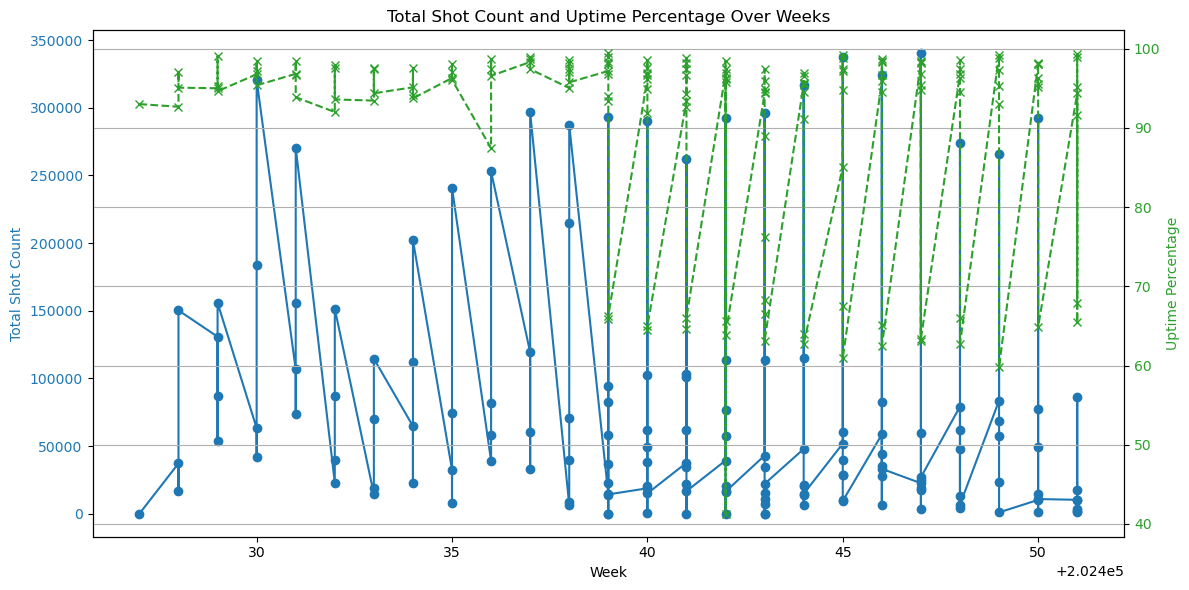

In [43]:
# Plot total shot count and uptime percentage on the same graph
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot total shot count
ax1.set_xlabel('Week')
ax1.set_ylabel('Total Shot Count', color='tab:blue')
ax1.plot(weekly_data['WEEK'], weekly_data['total_shot_count'], color='tab:blue', label='Total Shot Count', linestyle='-', marker='o')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis for uptime percentage
ax2 = ax1.twinx()
ax2.set_ylabel('Uptime Percentage', color='tab:green')
ax2.plot(weekly_data['WEEK'], weekly_data['uptime_percentage'], color='tab:green', label='Uptime Percentage', linestyle='--', marker='x')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Title and grid
plt.title('Total Shot Count and Uptime Percentage Over Weeks')
fig.tight_layout()
plt.grid(True)
plt.show()


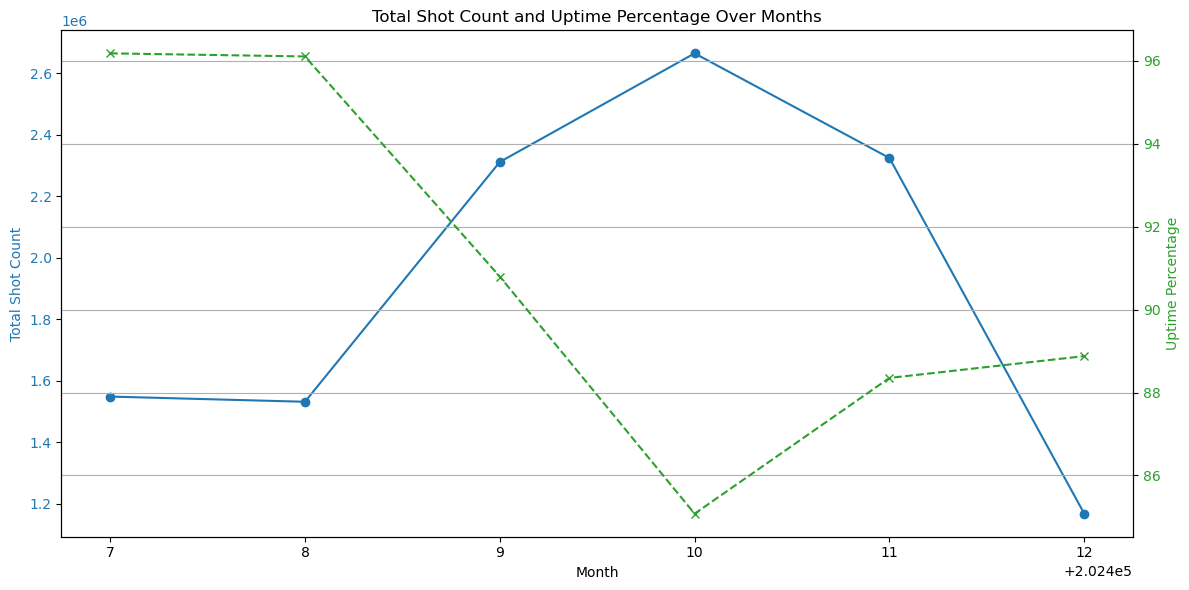

In [44]:
# Group by month for aggregation (assuming you have monthly_data)
monthly_data_aggregated = monthly_data.groupby('MONTH').agg(
    total_shot_count=('total_shot_count', 'sum'),  
    uptime_percentage=('uptime_percentage', 'mean')
).reset_index()

# Plot total shot count and uptime percentage on the same graph
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot total shot count
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Shot Count', color='tab:blue')
ax1.plot(monthly_data_aggregated['MONTH'], monthly_data_aggregated['total_shot_count'], color='tab:blue', label='Total Shot Count', linestyle='-', marker='o')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis for uptime percentage
ax2 = ax1.twinx()
ax2.set_ylabel('Uptime Percentage', color='tab:green')
ax2.plot(monthly_data_aggregated['MONTH'], monthly_data_aggregated['uptime_percentage'], color='tab:green', label='Uptime Percentage', linestyle='--', marker='x')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Title and grid
plt.title('Total Shot Count and Uptime Percentage Over Months')
fig.tight_layout()
plt.grid(True)
plt.show()


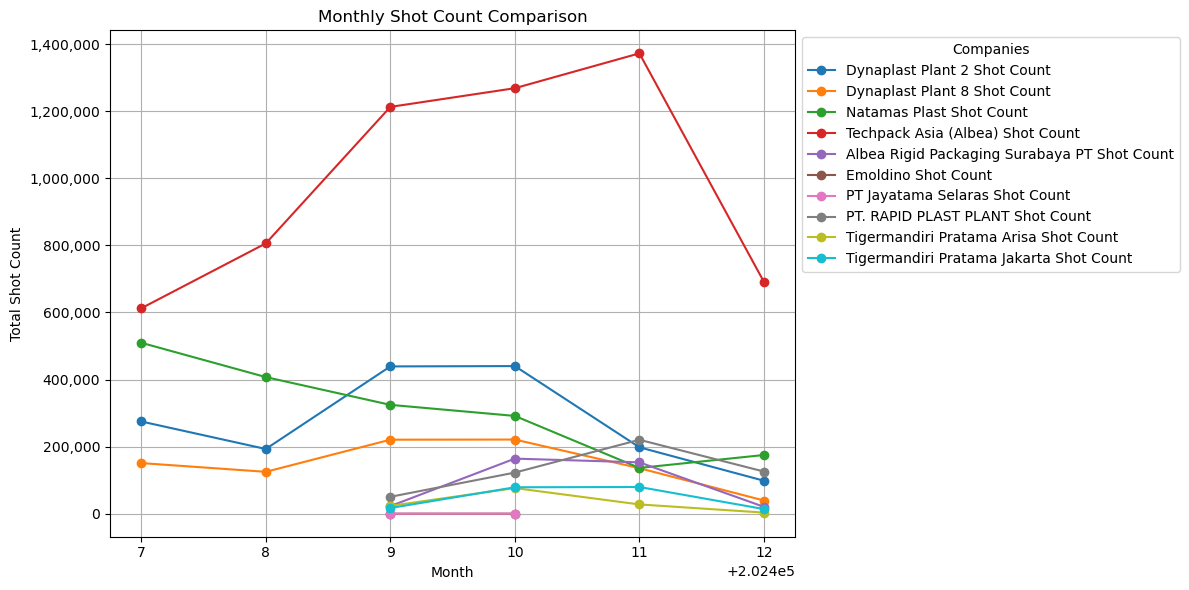

In [54]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Aggregating data by month
monthly_data = df_filtered.groupby(['YEAR', 'MONTH', 'COMPANY_NAME']).agg(
    total_shot_count=('SHOT_COUNT', 'sum')
).reset_index()

# Formatter function to display integers with commas
def format_with_commas(x, pos):
    return f'{int(x):,}'  # Format number with commas and as integer

# Plot
plt.figure(figsize=(12, 6))
for company in monthly_data['COMPANY_NAME'].unique():
    company_data = monthly_data[monthly_data['COMPANY_NAME'] == company]
    plt.plot(company_data['MONTH'], company_data['total_shot_count'], label=f'{company} Shot Count', marker='o')

plt.title('Monthly Shot Count Comparison')
plt.xlabel('Month')
plt.ylabel('Total Shot Count')

# Apply the custom formatter to the y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_with_commas))

# Move the legend outside of the plot area
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Companies', fontsize=10)

# Adjust layout to make room for the legend
plt.tight_layout()

# Show plot
plt.grid(True)
plt.show()


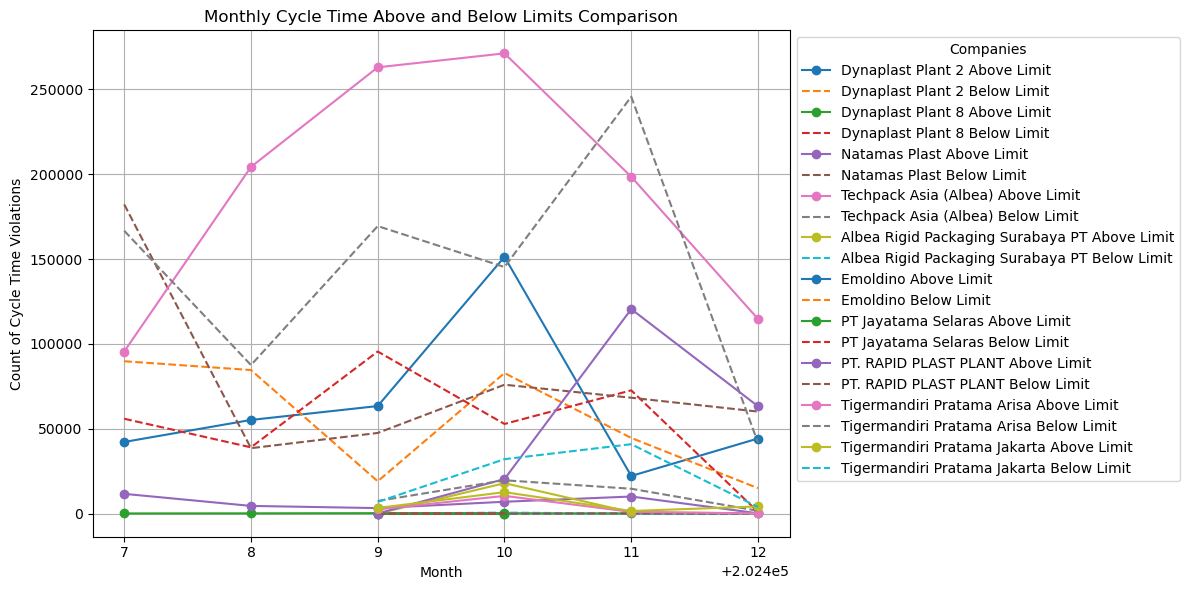

In [52]:
# Monthly aggregation for cycle time limits
cycle_time_limits = df_filtered.groupby(['YEAR', 'MONTH', 'COMPANY_NAME']).agg(
    above_count=('ABOVE_COUNT', 'sum'),
    below_count=('BELOW_COUNT', 'sum'),
    contracted_cycle_time=('CONTRACTED_CYCLE_TIME', 'mean')
).reset_index()

# Plot
plt.figure(figsize=(12, 6))
for company in cycle_time_limits['COMPANY_NAME'].unique():
    company_data = cycle_time_limits[cycle_time_limits['COMPANY_NAME'] == company]
    plt.plot(company_data['MONTH'], company_data['above_count'], label=f'{company} Above Limit', marker='o')
    plt.plot(company_data['MONTH'], company_data['below_count'], label=f'{company} Below Limit', linestyle='--')

plt.title('Monthly Cycle Time Above and Below Limits Comparison')
plt.xlabel('Month')
plt.ylabel('Count of Cycle Time Violations')

# Move the legend outside of the plot area
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Companies', fontsize=10)

# Adjust layout to make room for the legend
plt.tight_layout()

# Show plot
plt.grid(True)
plt.show()


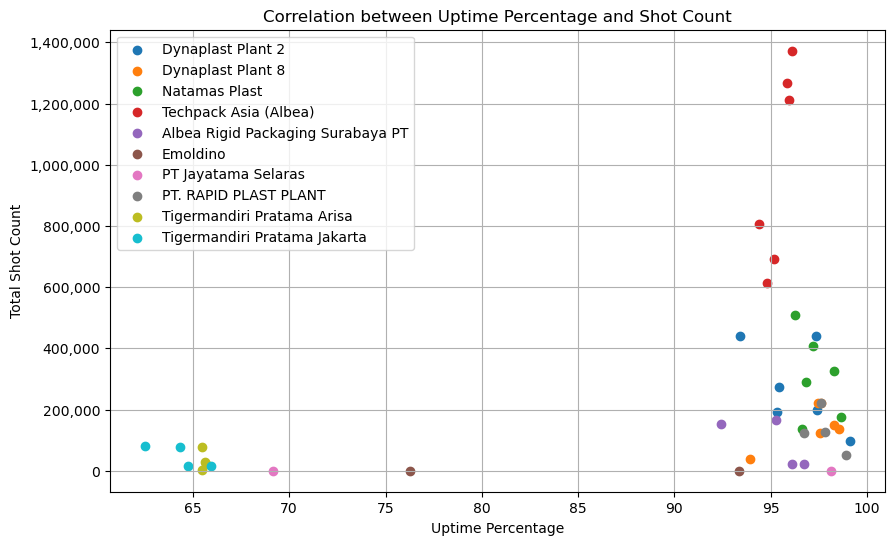

                       avg_uptime_percentage  total_shot_count
avg_uptime_percentage               1.000000          0.338159
total_shot_count                    0.338159          1.000000


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Correlation between uptime percentage and shot count
correlation_data = df_filtered.groupby(['YEAR', 'MONTH', 'COMPANY_NAME']).agg(
    total_shot_count=('SHOT_COUNT', 'sum'),
    avg_uptime_percentage=('UPTIME_PERCENTAGE', 'mean')
).reset_index()

# Formatter function to display integers with commas
def format_with_commas(x, pos):
    return f'{int(x):,}'  # Format number with commas and as integer

# Scatter plot to check correlation
plt.figure(figsize=(10, 6))
for company in correlation_data['COMPANY_NAME'].unique():
    company_data = correlation_data[correlation_data['COMPANY_NAME'] == company]
    plt.scatter(company_data['avg_uptime_percentage'], company_data['total_shot_count'], label=company)

# Title and labels
plt.title('Correlation between Uptime Percentage and Shot Count')
plt.xlabel('Uptime Percentage')
plt.ylabel('Total Shot Count')

# Apply the custom formatter to the y-axis for shot count
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_with_commas))

# Show the legend and grid
plt.legend()
plt.grid(True)

# Show plot
plt.show()

# Pearson correlation coefficient
correlation = correlation_data[['avg_uptime_percentage', 'total_shot_count']].corr()
print(correlation)

"""Weak Positive Correlation (0.34): The correlation of 0.34 suggests that there is a slight tendency for companies that have
    higher uptime percentages to also have a higher shot count, but it’s not a very strong relationship. 
    There could be other factors at play influencing the shot count.
"""


Correlation Matrix:
                       SHOT_COUNT  UPTIME_PERCENTAGE  CONTRACTED_CYCLE_TIME  \
SHOT_COUNT               1.000000           0.289723              -0.667856   
UPTIME_PERCENTAGE        0.289723           1.000000              -0.323177   
CONTRACTED_CYCLE_TIME   -0.667856          -0.323177               1.000000   
IDLE_TIME               -0.206439          -0.918298               0.296032   
PRODUCTION_TIME          0.414756           0.776795              -0.256323   

                       IDLE_TIME  PRODUCTION_TIME  
SHOT_COUNT             -0.206439         0.414756  
UPTIME_PERCENTAGE      -0.918298         0.776795  
CONTRACTED_CYCLE_TIME   0.296032        -0.256323  
IDLE_TIME               1.000000        -0.594347  
PRODUCTION_TIME        -0.594347         1.000000  


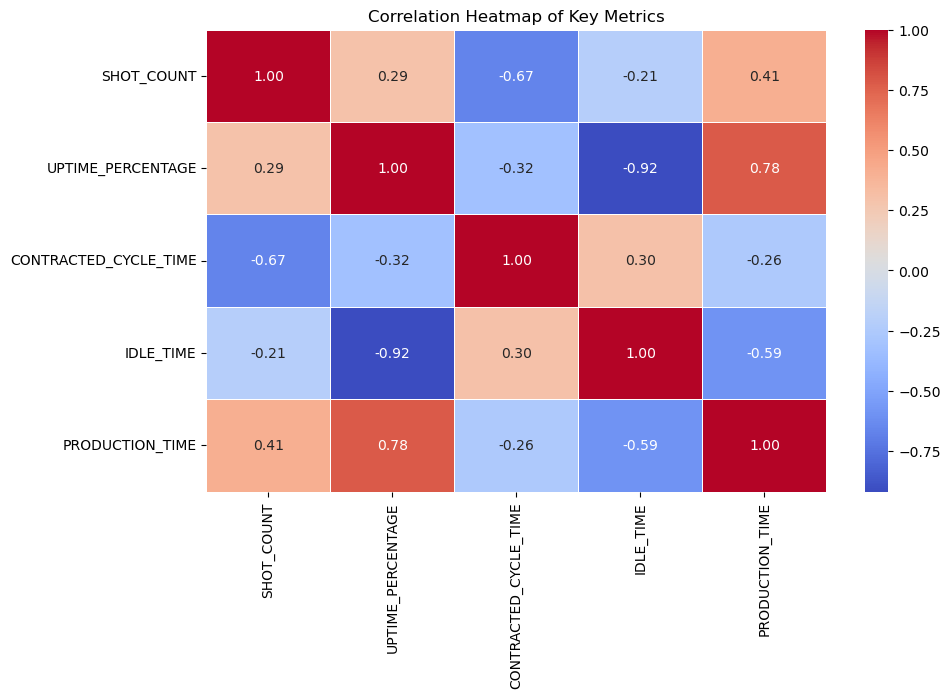

In [56]:
import seaborn as sns

# Create a correlation matrix
correlation_matrix = df_filtered[['SHOT_COUNT', 'UPTIME_PERCENTAGE', 'CONTRACTED_CYCLE_TIME', 'IDLE_TIME', 'PRODUCTION_TIME']].corr()

# Print the correlation matrix values
print("Correlation Matrix:")
print(correlation_matrix)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Key Metrics')
plt.show()


In [57]:
"""
     
   SHOT_COUNT and UPTIME_PERCENTAGE: 0.29

    There is a weak positive correlation between the total shot count and uptime percentage.
    This suggests that, to a small degree, as the shot count increases, the uptime percentage also tends to increase, but this relationship is not very strong.
    
SHOT_COUNT and CONTRACTED_CYCLE_TIME: -0.67

    There is a moderate negative correlation between shot count and contracted cycle time. 
    This means that, generally, as the shot count increases, the contracted cycle time decreases (or vice versa), but again, the relationship isn't perfect.
UPTIME_PERCENTAGE and CONTRACTED_CYCLE_TIME: -0.32

    This is a weak negative correlation between uptime percentage and contracted cycle time. 
    It indicates that as uptime percentage increases, the contracted cycle time tends to decrease a little, but this isn't a very strong relationship.
    
UPTIME_PERCENTAGE and IDLE_TIME: -0.92

    This is a strong negative correlation between uptime percentage and idle time. 
    It suggests that when uptime percentage is high, idle time is generally low, and when uptime percentage is low, idle time is high. 
    This makes sense because high uptime means the equipment is running more often, resulting in less idle time.
    
UPTIME_PERCENTAGE and PRODUCTION_TIME: 0.78

    This is a strong positive correlation. 
    It indicates that as uptime percentage increases, production time also tends to increase, which is expected because more uptime generally means more time spent on production.
    
CONTRACTED_CYCLE_TIME and IDLE_TIME: 0.30

    There is a weak positive correlation between contracted cycle time and idle time, meaning that as the cycle time increases, idle time also slightly tends to increase.
    However, the relationship is weak.
    
CONTRACTED_CYCLE_TIME and PRODUCTION_TIME: -0.26

    A weak negative correlation. As the contracted cycle time increases, production time tends to slightly decrease, but the relationship is not strong.
    
IDLE_TIME and PRODUCTION_TIME: -0.59

    There is a moderate negative correlation between idle time and production time. 
    This suggests that as idle time increases, production time tends to decrease, which makes sense: more idle time generally means less production time.
    
Summary of Key Insights:
    - Uptime percentage has a strong inverse relationship with idle time and a strong direct relationship with production time.
    - Shot count tends to be inversely related to contracted cycle time, but this is a moderate correlation.
    - Contracted cycle time is moderately negatively correlated with production time, meaning longer cycle times might slightly reduce production time. 

"""

"\n \n   SHOT_COUNT and UPTIME_PERCENTAGE: 0.29\n\nThere is a weak positive correlation between the total shot count and uptime percentage.\nThis suggests that, to a small degree, as the shot count increases, the uptime percentage also tends to increase, but this relationship is not very strong.\nSHOT_COUNT and CONTRACTED_CYCLE_TIME: -0.67\n\nThere is a moderate negative correlation between shot count and contracted cycle time. \nThis means that, generally, as the shot count increases, the contracted cycle time decreases (or vice versa), but again, the relationship isn't perfect.\nUPTIME_PERCENTAGE and CONTRACTED_CYCLE_TIME: -0.32\n\nThis is a weak negative correlation between uptime percentage and contracted cycle time. It indicates that as uptime percentage increases, the contracted cycle time tends to decrease a little, but this isn't a very strong relationship.\nUPTIME_PERCENTAGE and IDLE_TIME: -0.92\n\nThis is a strong negative correlation between uptime percentage and idle time. 

In [ ]:
"""
This script performs K-Means clustering on a dataset of companies based on key metrics:
- Total Shot Count
- Average Uptime Percentage
- Average Contracted Cycle Time

Steps involved in the analysis:

1. Data Preparation:
   - The dataset `df_filtered` is grouped by `COMPANY_NAME` and the following aggregated values are calculated:
     - Total Shot Count: The sum of the `SHOT_COUNT` for each company.
     - Average Uptime Percentage: The mean of the `UPTIME_PERCENTAGE` for each company.
     - Average Contracted Cycle Time: The mean of the `CONTRACTED_CYCLE_TIME` for each company.

2. Feature Scaling:
   - StandardScaler is used to scale the features `total_shot_count`, `avg_uptime_percentage`, and `avg_contracted_cycle_time` to standardize the values, ensuring they have a mean of 0 and a standard deviation of 1.

3.  K-Means Clustering:
   - The Elbow Method is used to determine the optimal number of clusters (k). 
     - The method iterates through `k = 1` to `k = 10` and calculates the `inertia` (sum of squared distances of samples to their nearest cluster center) for each value of k.
     - The Elbow Method is visualized by plotting the `inertia` values. The optimal number of clusters is chosen where the inertia value starts to flatten (in this case, it suggests `k = 3`).

4. K-Means with Optimal Clusters:
   - Using the Elbow Method's result, K-Means clustering is performed with `k = 3` clusters.
   - The `cluster` label is assigned to each company in the `company_data` DataFrame.

5. Visualization:
   - A pairplot of the clustered data is generated, with companies colored by their assigned cluster labels. This allows visualization of the relationships between the three key metrics across different clusters.

6. Silhouette Score:
   - The silhouette score is calculated to evaluate the quality of the clustering. 
     - A silhouette score close to +1 indicates that the clusters are well-separated and distinct, while a score close to 0 suggests that the clusters are overlapping. A negative score indicates that some data points may have been incorrectly clustered.
   - The silhouette score for this clustering is 0.60, indicating a moderately well-separated clustering solution.

7. Clustered Data:
   - The final output includes the `COMPANY_NAME`, `cluster` label, and the key metrics for each company, allowing an understanding of which companies belong to which clusters.

In the example output:
- The `company_data` DataFrame shows the assigned clusters for each company, their total shot count, average uptime percentage, and average contracted cycle time.
- For instance, `Dynaplast Plant 2` belongs to cluster 0, with a high shot count and uptime percentage, while `Emoldino` is in cluster 1 with a much lower shot count and uptime percentage.

This analysis helps in identifying groups of companies with similar operational characteristics, which can be used for targeted decision-making and further investigation into the factors driving the clustering results.
"""


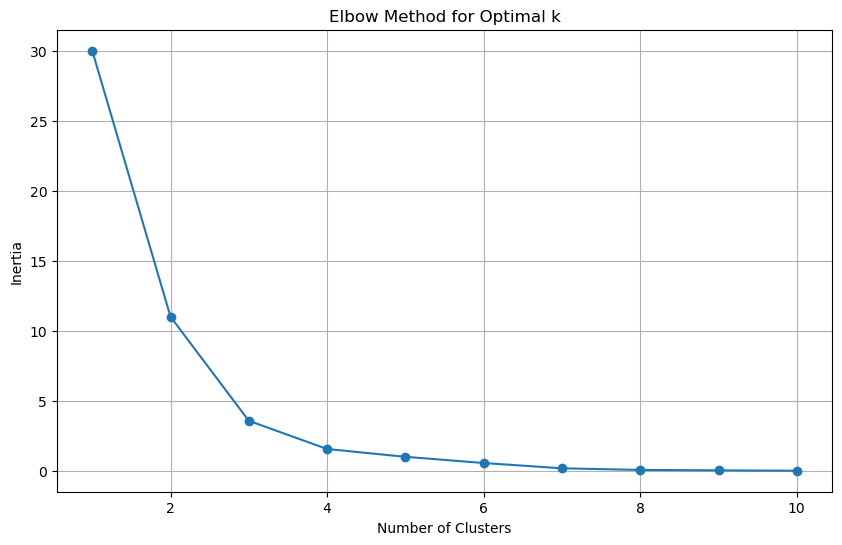

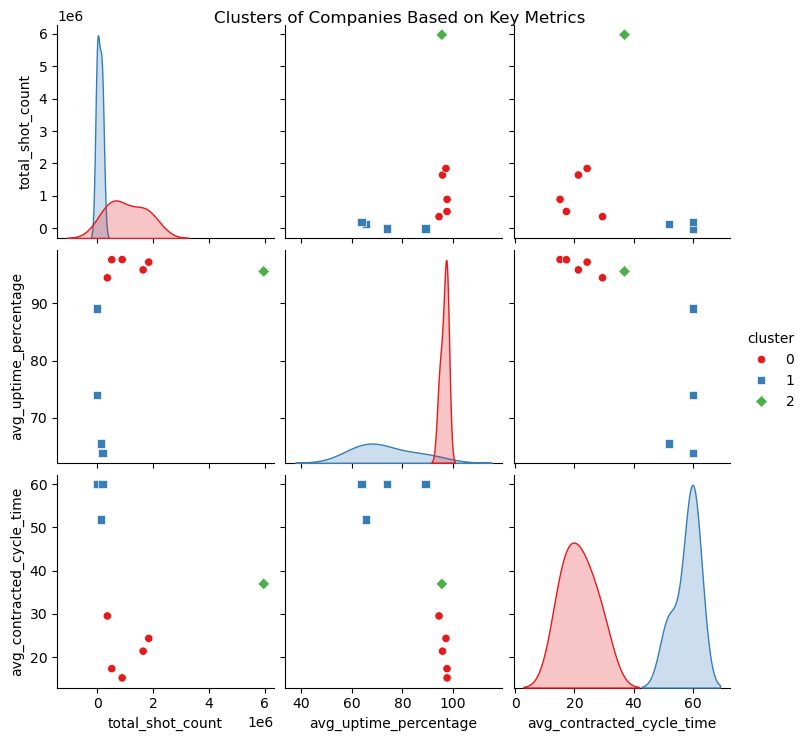

0.6046341373921825
                        COMPANY_NAME  cluster  total_shot_count  \
0  Albea Rigid Packaging Surabaya PT        0            360519   
1                  Dynaplast Plant 2        0           1643640   
2                  Dynaplast Plant 8        0            892710   
3                           Emoldino        1                31   
4                      Natamas Plast        0           1844685   
5                PT Jayatama Selaras        1               335   
6              PT. RAPID PLAST PLANT        0            519119   
7              Techpack Asia (Albea)        2           5964321   
8         Tigermandiri Pratama Arisa        1            130828   
9       Tigermandiri Pratama Jakarta        1            189207   

   avg_uptime_percentage  avg_contracted_cycle_time  
0              94.421928                  29.503924  
1              95.801467                  21.342019  
2              97.609116                  15.149879  
3              89.082500   

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans  
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import silhouette_score

# lets prepare the data
#group by company and agg the requriements  

company_data = df_filtered.groupby('COMPANY_NAME').agg(
    total_shot_count=('SHOT_COUNT', 'sum'), 
    avg_uptime_percentage=('UPTIME_PERCENTAGE', 'mean'),    
    avg_contracted_cycle_time=('CONTRACTED_CYCLE_TIME', 'mean'),    
).reset_index()

#scaling the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(company_data[['total_shot_count', 'avg_uptime_percentage', 'avg_contracted_cycle_time']])    

#appying kmeans
#we will use the elbow method to find the optimal number of clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_) # Sum of squared distances to closest cluster center
    
 #plotting the elbow method  
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)

#based on elbow method we can see that the optimal number of clusters is 3
#lets apply kmeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
company_data['cluster'] = kmeans.fit_predict(scaled_data)

#plotting the clusters
sns.pairplot(company_data, hue='cluster', palette='Set1',markers=["o", "s", "D"])
plt.suptitle('Clusters of Companies Based on Key Metrics')  
plt.show()

silhouette_score(scaled_data, company_data['cluster'])
print(silhouette_score(scaled_data, company_data['cluster']))   

#show the clustered data
print(company_data[['COMPANY_NAME', 'cluster', 'total_shot_count', 'avg_uptime_percentage', 'avg_contracted_cycle_time']])


    

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# lets prepare the data
features = ['CONTRACTED_CYCLE_TIME', 'IDLE_TIME', 'PRODUCTION_TIME'] #features
target = 'UPTIME_PERCENTAGE' #target

#selecting the relevant data
df_predict = df_filtered[features + [target]].dropna()

x = df_predict[features]
y = df_predict[target]

#splitting the data to train and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#train the model 
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

#make predictions 
y_pred = model.predict(x_test)  

#evaluate the model
mae= mean_absolute_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred)   

print(f'Mean Absolute Error: {mae}')
print(f'R2 Score: {r2}')

"""A lower MAE indicates a better model.
Here, an MAE of 0.0257 means that, on average, the model's predictions are off by about 2.57% of the target variable, which is quite good.

An R² score of 0.9997 suggests that your model is extremely accurate and fits the data very well, explaining 99.97% of the variance in the target."""


Mean Absolute Error: 0.025684202987802794
R2 Score: 0.9996590166953673


Anomaly Detection


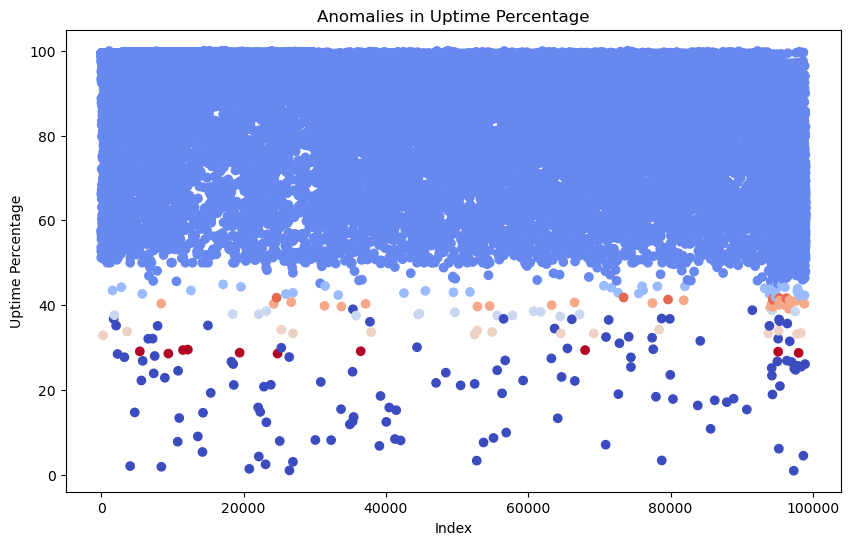

Anomalies detected:
       UPTIME_PERCENTAGE  Anomaly
1766               36.72       -1
2107               35.17       -1
2309               28.47       -1
3270               27.71       -1
4075                2.04       -1
...                  ...      ...
97547              24.73       -1
97859              25.69       -1
98306              25.46       -1
98648               4.48       -1
98879              26.09       -1

[122 rows x 2 columns]


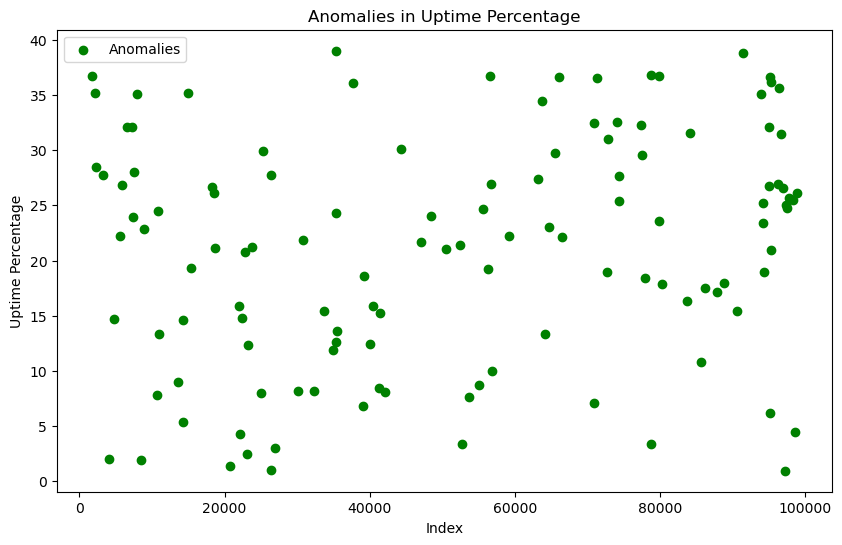

In [98]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Let's prepare the data for anomaly detection (using uptime percentage)
uptime_data = df_filtered[['UPTIME_PERCENTAGE']].dropna()

# Apply DBSCAN
db = DBSCAN(eps=0.5, min_samples=10)  # eps is the maximum distance between two samples for one to be considered as in the neighborhood of the other
uptime_data['Anomaly'] = db.fit_predict(uptime_data[['UPTIME_PERCENTAGE']])

# Plot the anomalies
plt.figure(figsize=(10, 6))
plt.scatter(uptime_data.index, uptime_data['UPTIME_PERCENTAGE'], c=uptime_data['Anomaly'], cmap='coolwarm')
plt.title('Anomalies in Uptime Percentage')
plt.xlabel('Index')
plt.ylabel('Uptime Percentage')
plt.show()

# Print the anomalies detected
anomalies = uptime_data[uptime_data['Anomaly'] == -1]
print('Anomalies detected:')
print(anomalies)

# Plot the anomalies separately
plt.figure(figsize=(10, 6))
plt.scatter(anomalies.index, anomalies['UPTIME_PERCENTAGE'], color='green', label='Anomalies')
plt.title('Anomalies in Uptime Percentage')
plt.xlabel('Index')
plt.ylabel('Uptime Percentage')
plt.legend()
plt.show()


efficiency metrics for companies 

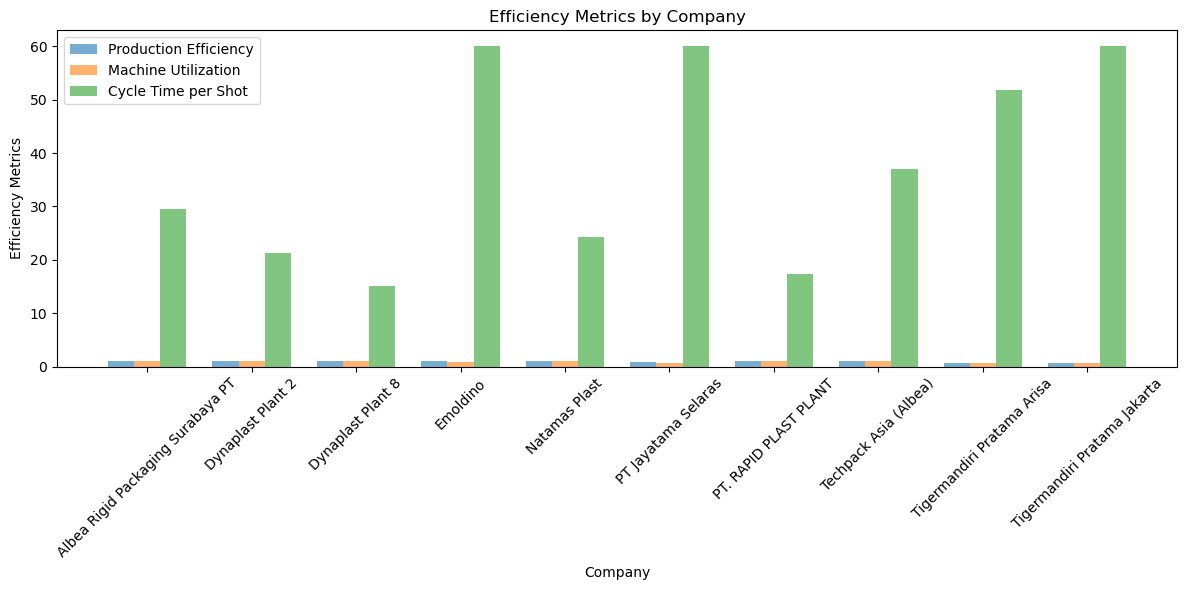

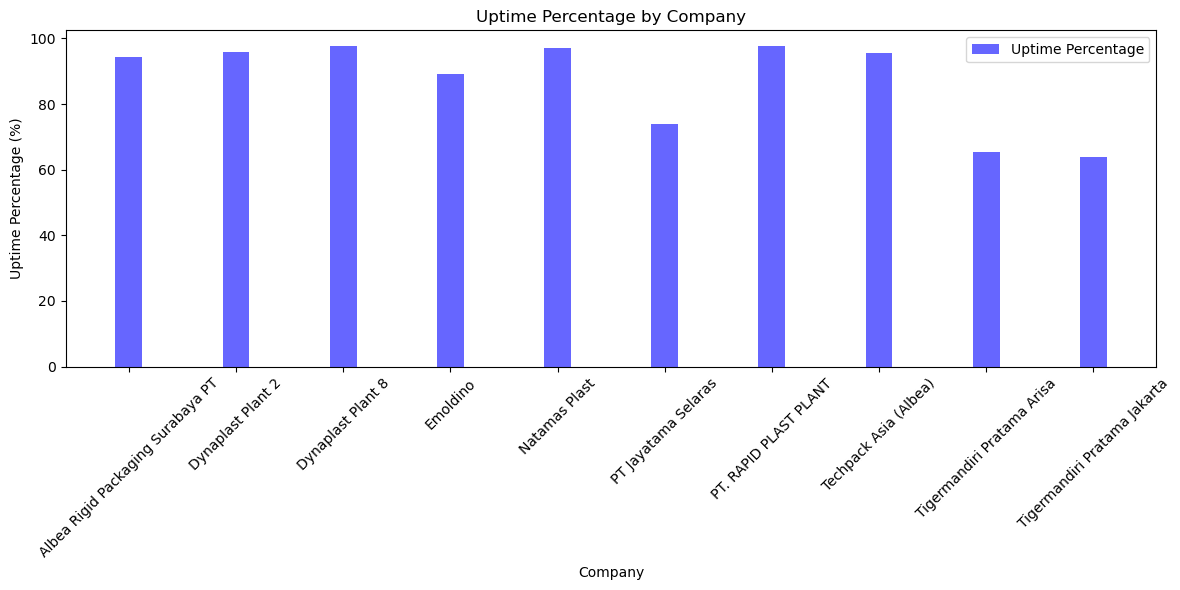

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# Efficiency metrics for the model
"""
1. production efficiency: the ratio of production time to total time (production time + idle time)
2. machine utilization: the uptime percentage
3. cycle time per shot: the average time taken to produce a single shot
"""

# Calculate the metrics for each company
company_efficiency = df_filtered.groupby('COMPANY_NAME').agg(
    total_production_time=('PRODUCTION_TIME', 'sum'),
    total_idle_time=('IDLE_TIME', 'sum'),
    total_shot_count=('SHOT_COUNT', 'sum'),
    avg_contracted_cycle_time=('CONTRACTED_CYCLE_TIME', 'mean'),
    avg_uptime_percentage=('UPTIME_PERCENTAGE', 'mean'),  # Uptime percentage for machine utilization
).reset_index()

# Calculate production efficiency
company_efficiency['production_efficiency'] = company_efficiency['total_production_time'] / (company_efficiency['total_production_time'] + company_efficiency['total_idle_time'])

# Machine utilization is now based on uptime percentage
company_efficiency['machine_utilization'] = company_efficiency['avg_uptime_percentage'] / 100  # Convert percentage to a ratio

# If cycle time per shot is zero or negative, we can safely ignore those companies
company_efficiency['cycle_time_per_shot'] = company_efficiency['avg_contracted_cycle_time'].fillna(0)

# Set the figure size for the first plot
plt.figure(figsize=(12, 6))

# Define bar width
bar_width = 0.25

# Define the positions of the bars on the x-axis
x_pos = np.arange(len(company_efficiency))

# Plot production efficiency (shifted by -bar_width)
plt.bar(x_pos - bar_width, company_efficiency['production_efficiency'], width=bar_width, alpha=0.6, label='Production Efficiency')

# Plot machine utilization (shifted by 0)
plt.bar(x_pos, company_efficiency['machine_utilization'], width=bar_width, alpha=0.6, label='Machine Utilization')

# Plot cycle time per shot (shifted by +bar_width)
plt.bar(x_pos + bar_width, company_efficiency['cycle_time_per_shot'], width=bar_width, alpha=0.6, label='Cycle Time per Shot')

# Labeling and title
plt.xlabel('Company')
plt.ylabel('Efficiency Metrics')
plt.title('Efficiency Metrics by Company')

# Show legend
plt.legend()

# Rotate the x-axis labels and adjust layout for better readability
plt.xticks(x_pos, company_efficiency['COMPANY_NAME'], rotation=45)
plt.tight_layout()  # Adjust the layout to ensure everything fits properly

# Show the first plot
plt.show()

# Set the figure size for the second plot (Uptime Percentage)
plt.figure(figsize=(12, 6))

# Plot Uptime Percentage as a bar plot
plt.bar(x_pos, company_efficiency['avg_uptime_percentage'], width=bar_width, alpha=0.6, color='blue', label='Uptime Percentage')

# Labeling and title for the second plot
plt.xlabel('Company')
plt.ylabel('Uptime Percentage (%)')
plt.title('Uptime Percentage by Company')

# Show legend
plt.legend()

# Rotate the x-axis labels and adjust layout for better readability
plt.xticks(x_pos, company_efficiency['COMPANY_NAME'], rotation=45)
plt.tight_layout()  # Adjust the layout to ensure everything fits properly

# Show the second plot (Uptime Percentage)
plt.show()


RCA ( root cause analysis)

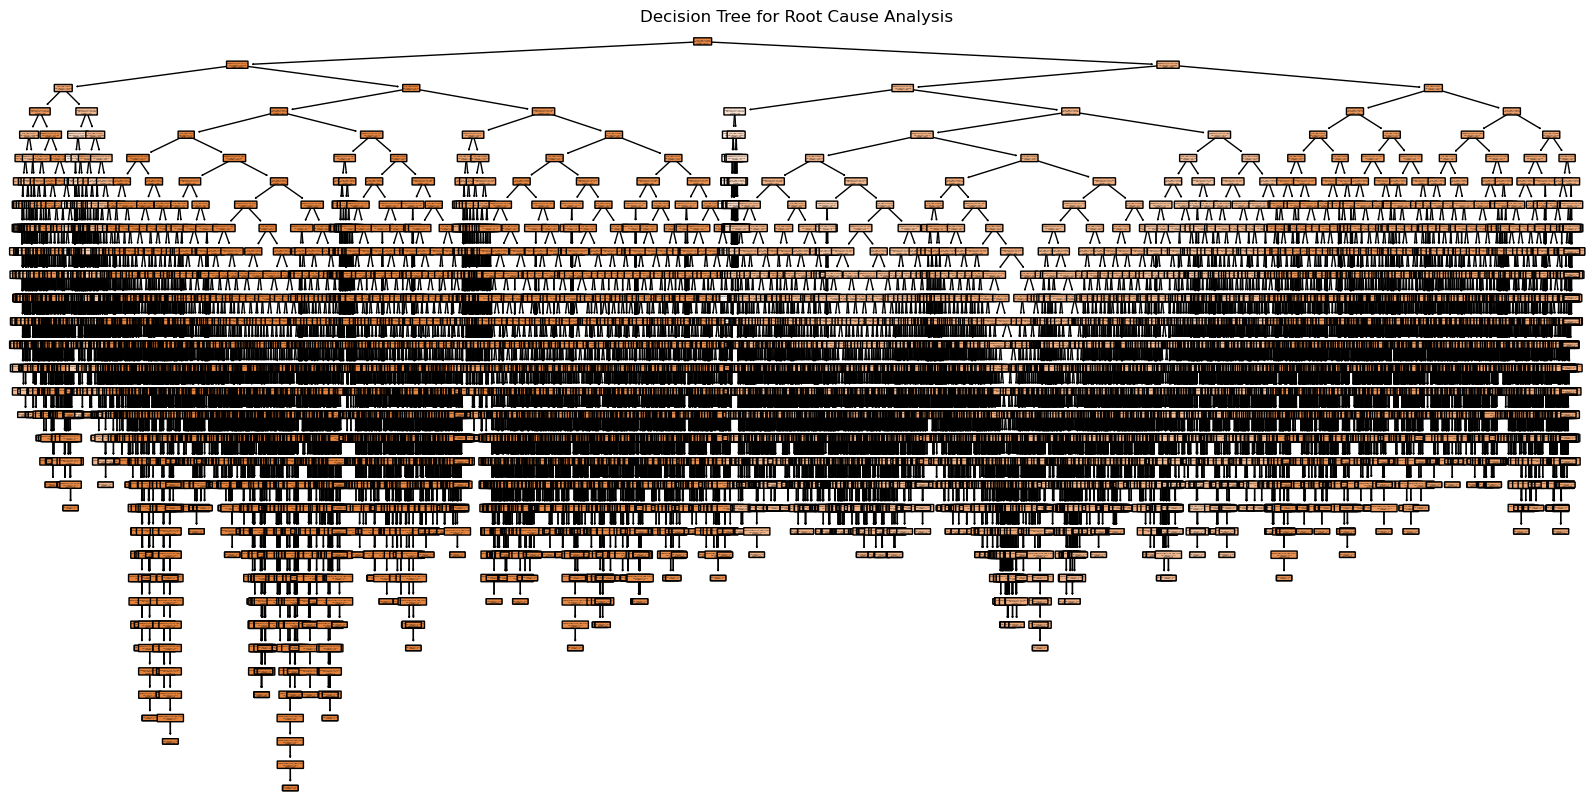

In [109]:
# RCA using decision trees 
"""
1. prepare the data : we will use relevant feautures like cycle time, idle time, production time, and uptime percentage
2. train the model : we will use a decision tree regressor to predict the root cause
3. interpret the results : we will analyze the feature importance to understand the root cause with visualizations   

explanation of the features:
1. decision tree : we train a decision tree regressor to predict uptime percentage on key feautures like cycle time, idle time, and production time
2. visualizing the tree : we plot the decision tree to show how the decisions are made based on features 
"""

from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Prepare the data
# Drop rows where either features or target is missing
df_cleaned = df_filtered.dropna(subset=['CONTRACTED_CYCLE_TIME', 'IDLE_TIME', 'PRODUCTION_TIME', 'UPTIME_PERCENTAGE'])

# Define the features and target
x = df_cleaned[['CONTRACTED_CYCLE_TIME', 'IDLE_TIME', 'PRODUCTION_TIME']]
y = df_cleaned['UPTIME_PERCENTAGE']

# Train the model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(x, y)

# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=x.columns, filled=True, rounded=True)
plt.title('Decision Tree for Root Cause Analysis')
plt.show()




Optimization for cycle time efficiency (linear programming)

In [111]:
from scipy.optimize import linprog

# Define the coefficients for the objective function (e.g., minimize contracted cycle time per shot)
c = [1]  # Here, we might want to minimize some weighted combination of cycle time, uptime, etc.

# Define the constraints matrix (based on production time, idle time, etc.)
A = [
    [1],  # Production time constraint (e.g., minimum production time per day)
    [-1],  # Idle time constraint (e.g., minimize idle time)
    [1]  # Uptime percentage constraint (e.g., minimum uptime percentage)
]

# Define the right-hand side values of the constraints (e.g., limits for production time, idle time, uptime percentage)
b = [
    50000,  # Minimum production time constraint (example: 50,000 units produced)
    -10000,  # Idle time should be less than 10,000 (minimize idle time)
    90  # Uptime percentage should be greater than 90%
]

# Bounds for the cycle time (e.g., cycle time should be between 0 and 100 units)
x_bounds = (0, 100)

# Bounds for the other variables
bounds = [x_bounds]

# Call linprog to solve the linear programming problem
result = linprog(c, A_ub=A, b_ub=b, bounds=[x_bounds], method='highs')

# Check if the optimization was successful and print the result
if result.success:
    print(f"Optimized cycle time per shot: {result.fun}")
else:
    print(f"Optimization failed: {result.message}")
    print(f"Status: {result.status}")
    print(f"Constrained values: {result.x}")  # Check the values of the variables


Optimization failed: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is At lower/fixed bound)
Status: 2
Constrained values: None


In [113]:
# Example with non-trivial constraints
c = [1]  # Objective: minimize cycle time per shot

# Constraints for production time and idle time (we can modify values as needed)
A = [
    [1],   # Coefficient for production time
    [-1],  # Coefficient for idle time
    [1]    # Coefficient for uptime percentage
]

# Right-hand side values for constraints (example values)
b = [50000, 10000, 90]

# Bounds for cycle time (we can adjust as needed)
x_bounds = (0, 1000)

result = linprog(c, A_ub=A, b_ub=b, bounds=[x_bounds], method='simplex', options={"disp": True})

if result.success:
    print(f"Optimized cycle time per shot: {result.fun}")
else:
    print(f"Optimization failed: {result.message}")
    print(f"Status: {result.status}")
    print(f"Constrained values: {result.x}")


The solution was determined in presolve as there are no non-trivial constraints.
         Current function value: 0.000000    
         Iterations: 0
Optimized cycle time per shot: 0.0


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_84642/2085628588.py:17: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  result = linprog(c, A_ub=A, b_ub=b, bounds=[x_bounds], method='simplex', options={"disp": True})


Time to Value analysis

Average Uptime Percentage Before Change: 95.35893123298675
Average Uptime Percentage After Change: 93.25666746694246


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_84642/3388109217.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['START_TIME'] = pd.to_datetime(df_filtered['START_TIME'])


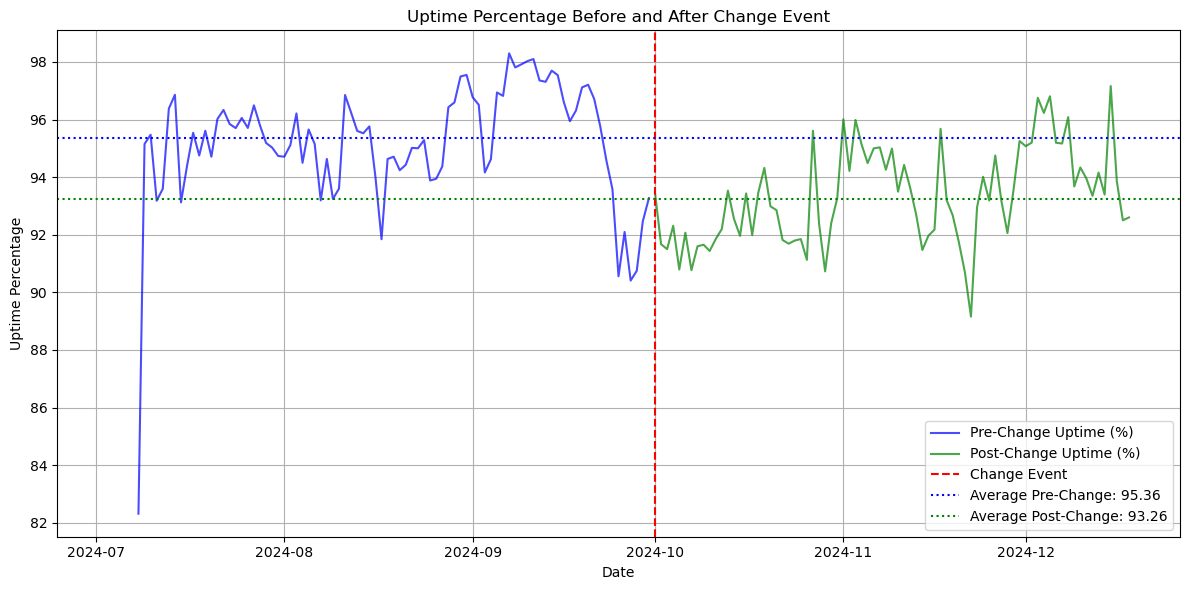

In [118]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Convert the 'START_TIME' to datetime
df_filtered['START_TIME'] = pd.to_datetime(df_filtered['START_TIME'])

# Define the change event date
change_event = pd.to_datetime('2024-10-01')

# Split the data into pre-change and post-change datasets
prechange_data = df_filtered[df_filtered['START_TIME'] < change_event]
postchange_data = df_filtered[df_filtered['START_TIME'] >= change_event]

# Calculate average uptime percentage before and after the change
avg_prechange_uptime = prechange_data['UPTIME_PERCENTAGE'].mean()
avg_postchange_uptime = postchange_data['UPTIME_PERCENTAGE'].mean()

print(f'Average Uptime Percentage Before Change: {avg_prechange_uptime}')
print(f'Average Uptime Percentage After Change: {avg_postchange_uptime}')

# Resample the data to get daily averages
prechange_daily_avg = prechange_data.resample('D', on='START_TIME')['UPTIME_PERCENTAGE'].mean()
postchange_daily_avg = postchange_data.resample('D', on='START_TIME')['UPTIME_PERCENTAGE'].mean()

# Plotting
plt.figure(figsize=(12, 6))

# Plot daily averages
plt.plot(prechange_daily_avg.index, prechange_daily_avg, label='Pre-Change Uptime (%)', color='blue', alpha=0.7)
plt.plot(postchange_daily_avg.index, postchange_daily_avg, label='Post-Change Uptime (%)', color='green', alpha=0.7)

# Mark the change event
plt.axvline(change_event, color='red', linestyle='--', label='Change Event')

# Add average lines for pre-change and post-change
plt.axhline(avg_prechange_uptime, color='blue', linestyle=':', label=f'Average Pre-Change: {avg_prechange_uptime:.2f}')
plt.axhline(avg_postchange_uptime, color='green', linestyle=':', label=f'Average Post-Change: {avg_postchange_uptime:.2f}')

# Title and labels
plt.title('Uptime Percentage Before and After Change Event')
plt.xlabel('Date')
plt.ylabel('Uptime Percentage')
plt.legend()

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()


In [119]:
"""
additional insights:
1. track improvement over time : we can track the improvement in production efficiency over time to see if any changes or initiatives have had a positive impact
2. identify lag times : we can identify any lag times between changes or events and their impact on production efficiency


explanations of the features:
1. pre-change and post change uptime: i calculated the average uptime percentage before and after the change event to compare the production efficiency
2. plotting : i visualized the change event and the uptime percentage before and after the change to understand the impact of the event on production efficiency
3. time_to_value : i calculated the time it took for the production efficiency to improve after the change event to understand the lag time between the event and its impact
"""

postchange_data_sorted= postchange_data.sort_values(by ='START_TIME')
first_improvement_date = postchange_data_sorted[postchange_data_sorted['UPTIME_PERCENTAGE'] > avg_prechange_uptime].iloc[0]['START_TIME']


#calculate the time it took for improvement to show 
time_to_value = first_improvement_date - change_event   
print(f'Time to First Improvement: {time_to_value}')    

Time to First Improvement: 0 days 00:02:21


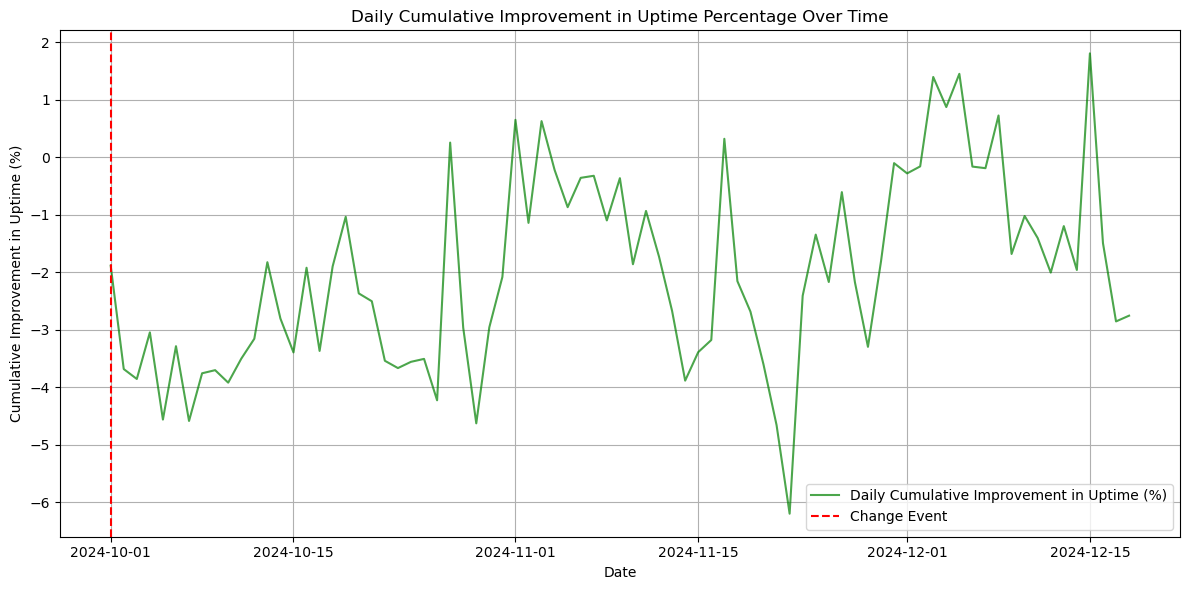

In [122]:
# Resample the data by day (or use any other suitable frequency like 'H' for hourly, 'W' for weekly)
postchange_data_sorted.set_index('START_TIME', inplace=True)
daily_cumulative_improvement = postchange_data_sorted['cumulative_improvement'].resample('D').mean()

# Plot the resampled data
plt.figure(figsize=(12, 6))
plt.plot(daily_cumulative_improvement.index, daily_cumulative_improvement, label='Daily Cumulative Improvement in Uptime (%)', color='green', alpha=0.7)

# Mark the change event
plt.axvline(change_event, color='red', linestyle='--', label='Change Event')

# Title and labels
plt.title('Daily Cumulative Improvement in Uptime Percentage Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Improvement in Uptime (%)')
plt.legend()

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()


In [121]:
# Identify the date when uptime consistently exceeds the pre-change average
consistent_improvement = postchange_data_sorted[postchange_data_sorted['UPTIME_PERCENTAGE'] > avg_prechange_uptime]
if not consistent_improvement.empty:
    consistent_improvement_start = consistent_improvement.iloc[0]['START_TIME']
    print(f'Uptime remained consistently above pre-change average from: {consistent_improvement_start}')
else:
    print('Uptime did not consistently improve above the pre-change average.')


Uptime remained consistently above pre-change average from: 2024-10-01 00:02:21


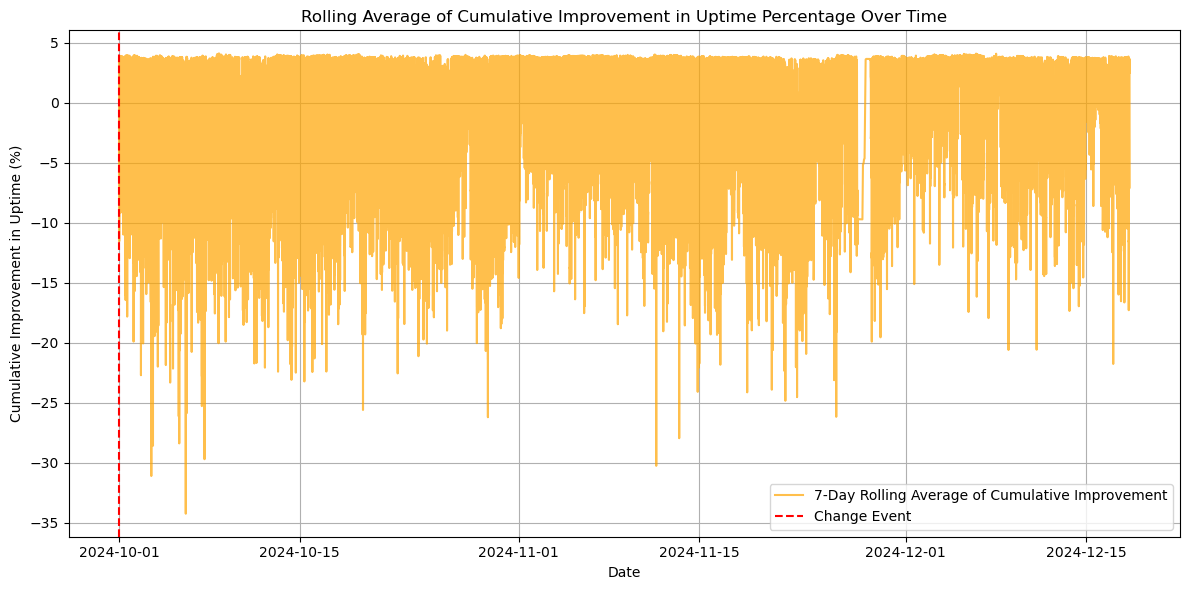

In [123]:
# Calculate a rolling average (e.g., 7-day window) of cumulative improvement
rolling_avg = postchange_data_sorted['cumulative_improvement'].rolling(window=7).mean()

# Plot the rolling average
plt.figure(figsize=(12, 6))
plt.plot(rolling_avg.index, rolling_avg, label='7-Day Rolling Average of Cumulative Improvement', color='orange', alpha=0.7)

# Mark the change event
plt.axvline(change_event, color='red', linestyle='--', label='Change Event')

# Title and labels
plt.title('Rolling Average of Cumulative Improvement in Uptime Percentage Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Improvement in Uptime (%)')
plt.legend()

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()


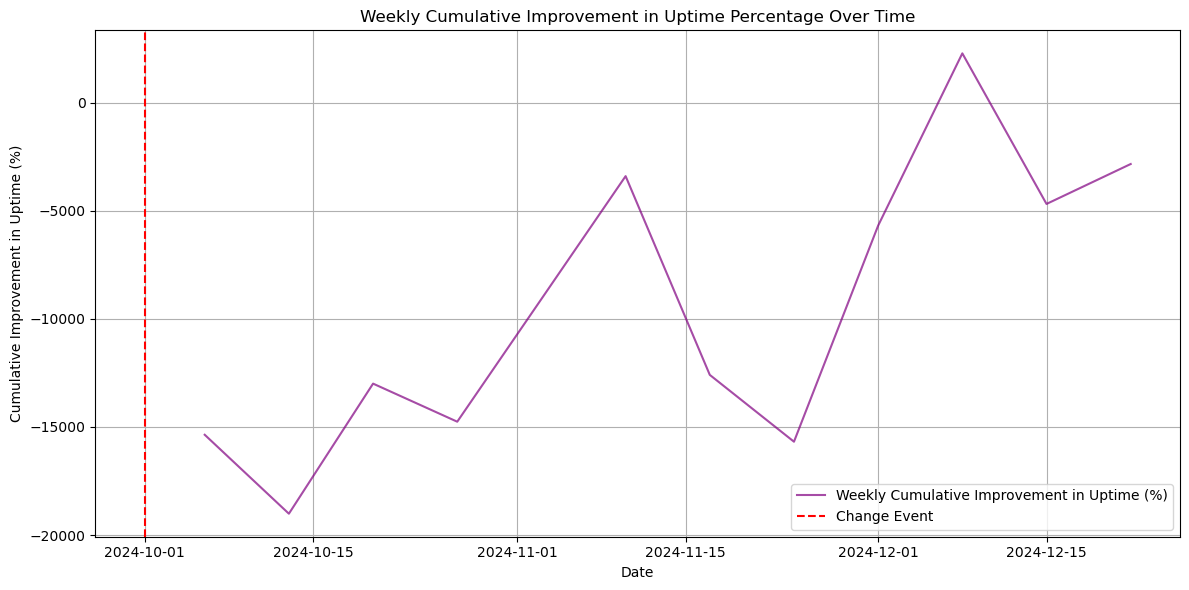

In [124]:
# Create weekly cumulative improvement
weekly_cumulative_improvement = postchange_data_sorted['cumulative_improvement'].resample('W').sum()

# Plot weekly cumulative improvement
plt.figure(figsize=(12, 6))
plt.plot(weekly_cumulative_improvement.index, weekly_cumulative_improvement, label='Weekly Cumulative Improvement in Uptime (%)', color='purple', alpha=0.7)

# Mark the change event
plt.axvline(change_event, color='red', linestyle='--', label='Change Event')

# Title and labels
plt.title('Weekly Cumulative Improvement in Uptime Percentage Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Improvement in Uptime (%)')
plt.legend()

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()


Churn analysis for cycle time 

In [88]:
"""
For Churn Analysis, we can look for patterns or anomalies in cycle time data that could indicate potential churn or reduced engagement by the client. 
The idea is to identify signals in the cycle time trends, where increases or variations could reflect a loss of interest or declining service satisfaction,
potentially leading to churn.

steps to take 

1. define churn : in here, churn can be defined as a decrease in cycle time or an increase in cycle time variability, indicating a potential loss of interest or engagement by the client

2. prepare the data : we will use cycle time data to identify patterns or anomalies that could indicate churn

3. predict churn : we will use anomaly detection techniques or clustering to identify potential churn signals in the cycle time data    

4. evaluate the results : we will evaluate the results to understand the potential churn signals and take appropriate actions to address them 


"""

#feature engineering 
#calculate the cycle time variability for each company

churn_data = df_filtered.groupby(['YEAR', 'MONTH' ,'COMPANY_NAME']).agg( 
        avg_cycle_time=('CONTRACTED_CYCLE_TIME', 'mean'),    
        total_shot_count=('SHOT_COUNT', 'sum') ,
        total_above_violations=('ABOVE_COUNT', 'sum'), 
        total_below_violations=('BELOW_COUNT', 'sum')
).reset_index()

#generating a churn indicator 
churn_data['churn_risk'] = (churn_data['avg_cycle_time'] > churn_data['avg_cycle_time'].quantile(0.75)) & \
                            (churn_data['total_shot_count'] < churn_data['total_shot_count'].quantile(0.25))
                            

churn_data.head()                        
                            


                                                                         
                                                     


,YEAR,MONTH,COMPANY_NAME,avg_cycle_time,total_shot_count,total_above_violations,total_below_violations,churn_risk
0,2024,202407,Dynaplast Plant 2,21.097897,274991,42254,89787,False
1,2024,202407,Dynaplast Plant 8,15.089888,150940,160,55923,False
2,2024,202407,Natamas Plast,26.625146,509678,11698,182163,False
3,2024,202407,Techpack Asia (Albea),39.388748,612585,95527,166632,False
4,2024,202408,Dynaplast Plant 2,22.888781,192972,55218,84608,False


In [89]:
#building a predictive model for churn
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

#prepare the data
x = churn_data[['avg_cycle_time', 'total_shot_count', 'total_above_violations', 'total_below_violations']]
y = churn_data['churn_risk']

#split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


#logictic regression model
model = LogisticRegression()
model.fit(x_train, y_train)

#make predictions
y_pred = model.predict(x_test)

#evaluate the model
print(classification_report(y_test, y_pred))

"""Step 3: Insights and Monitoring
This model will classify companies at high risk of churn based on cycle time and related features. 
By monitoring the churn risk over time, we can proactively engage clients that might be at risk of leaving.

"""




 


              precision    recall  f1-score   support

       False       1.00      0.88      0.93         8
        True       0.50      1.00      0.67         1

    accuracy                           0.89         9
   macro avg       0.75      0.94      0.80         9
weighted avg       0.94      0.89      0.90         9



In [ ]:
"""Key Metrics in the Classification Report:

Precision: This measures the proportion of correct positive predictions (True churn risk) out of all positive predictions made by the model.

False: For the companies that are not at risk of churn, the model correctly predicted them as not at risk 100% of the time, which is excellent (precision = 1.00).
True: For the companies that are at risk of churn, the model correctly predicted them as at risk 50% of the time, which is relatively poor.

Recall: This measures how well the model captures the positive class (True churn risk).

False: The recall for False churn risk is 0.88, meaning the model missed 12% of companies that should have been classified as not at risk.
True: The recall for True churn risk is 1.00, meaning the model identified all the companies that were actually at risk of churn, which is ideal.

F1-Score: The F1-score is the harmonic mean of precision and recall. It balances both metrics and is useful when the class distribution is imbalanced (as in your case).

False: The F1-score for False churn risk is 0.93, which is quite good, as it indicates that the model is doing well at correctly identifying companies that are not at risk.
True: The F1-score for True churn risk is 0.67, which is lower, indicating that while the recall is perfect (100%), the precision is low (50%), 
leading to an imbalance between false positives and true positives.

Accuracy: The accuracy of the model is 0.89 (89%), meaning that 89% of the total predictions are correct. 
However, accuracy can be misleading when classes are imbalanced, as in your case, where the True churn risk class is much less frequent.

Support: This refers to the number of occurrences of each class in the test set.

There are 8 instances of False churn risk (companies not at risk of churn) and 1 instance of True churn risk (company at risk of churn) in the test set.
This imbalance influences the model's performance metrics.

Insights and Next Steps:

Imbalanced Classes: There is a significant imbalance between the classes (only 1 positive instance of churn risk), which is why the recall for True churn risk is 1.00 but the precision is low.
The model is biased towards predicting the majority class (False churn risk) because of the class imbalance.

Precision vs. Recall Trade-off: The model has a high recall for True churn risk, meaning it correctly identifies churn risk when it exists, but the precision for churn risk is low. 
This means it also predicts churn risk when it doesn't exist, leading to false positives.

Improvement: To improve the model:

Handle Imbalance: You can address the imbalance using techniques such as SMOTE (Synthetic Minority Over-sampling Technique) or class weighting in the model.
Feature Engineering: More features related to cycle time variability, production anomalies, or engagement levels might improve the model's ability to predict churn.
Hyperparameter Tuning: Adjust the model's hyperparameters (e.g., C in logistic regression) to control regularization and potentially improve precision for True churn risk.
Proactive Monitoring: Based on this model, you can identify companies that are at risk of churn (even if the model is currently not perfect) and take actions to engage them before they leave."""

Market Basket Analysis

In [130]:
"""For Market Basket Analysis, we'll assume that maintenance services, upgrades, or machine parts are available as additional services.
We can look for frequent patterns in purchases or service usage to recommend related products or services.

To perform Market Basket Analysis, we’ll need data where purchases or services are recorded (e.g., clients purchasing machine upgrades, or maintenance services at the same time as production).
We can use Apriori Algorithm or FP-Growth to identify frequent itemsets.

For simplicity, let’s assume you have a transaction-like dataset of service purchases. 
"""
# we dont have this data so i am only leaving this here as an example for future
from mlxtend.frequent_patterns import apriori, association_rules

transaction_data = df_filtered[['COMPANY_NAME', 'MAINTENANCE_SERVICE', 'MACHINE_UPGRADE', 'SERVICE_PACKAGE']]
transaction_data = transaction_data.applymap(lambda x: 1 if x else 0)

#applying apriori algorithm
frequent_itemsets = apriori(transaction_data, min_support=0.1, use_colnames=True)

#getting association rules
association_rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.7)

#print the association rules    
print(association_rules.head())



KeyError: "['MAINTENANCE_SERVICE', 'MACHINE_UPGRADE', 'SERVICE_PACKAGE'] not in index"